# Forced Kernel 

1. Synthetic `Havlicek` dataset with a specific quantum circuit
2. Kernel made with that quantum circuit
3. Train SVM
    - Classical kernel is expected to fail
    - Quantum kernel has to have 1.0 accuracy

In [3]:
import matplotlib.pyplot as plt
import pennylane as qml
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

from src.data.synthetic import *
from src.utils.visuals import *
from src.data.preprocessing import preprocess_synthetic
from src.optimization.classical_base import classical_benchmark

## 0. Classical Benchmarking

In [4]:
deltas = np.linspace(0.1, 0.6, 10)
accuracies_classic, errs_classic = [], []
for delta in deltas:
    accs = []
    for seed in range(9):
        X, y = Havlicek_synthetic_dataset(seed=seed, delta=delta)
        X_train, X_test, y_train, y_test = preprocess_synthetic(X, y, N_QUBITS)
        results = classical_benchmark(X_train, y_train, X_test, y_test)
        accs.append(results['accuracy'])
    accuracies_classic.append(np.mean(accs))
    errs_classic.append(np.std(accs))

data = {'deltas': deltas, 'acc classic': accuracies_classic, 'err classic': errs_classic}
df = pd.DataFrame(data)
df.to_csv('Results/ForcedKernel Benchmark/ClassicalPerformance.csv', index=False)

In [ ]:
df = pd.read_csv('Results/ForcedKernel Benchmark/ClassicalPerformance.csv')
deltas, accuracies_classic, errs_classic = df['deltas'], df['acc classic'], df['err classic']

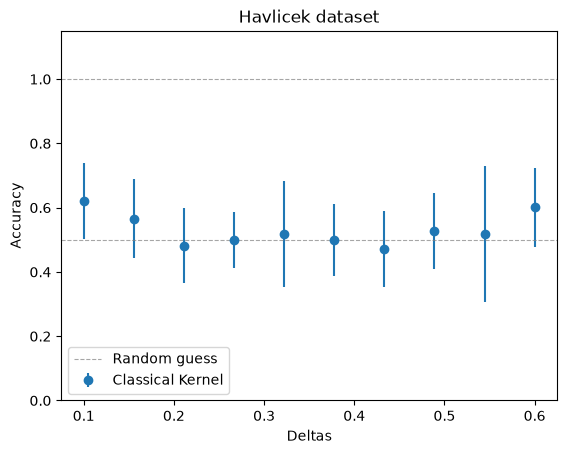

In [8]:
plt.errorbar(deltas, accuracies_classic, yerr=errs_classic, fmt='o', label='Classical Kernel')
plt.ylabel('Accuracy')
plt.xlabel('Deltas')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, label='Random guess')
plt.axhline(1, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
plt.title('Havlicek dataset')
plt.legend()
plt.ylim(0, 1.15)
plt.show()

## 1. Forced Kernel

Objective: Find a kernel that has 1.0 accuracy vs a classical with roughly 0.5 accuracy $\rightarrow$ done.   
> This kernel is not trained. It's made with how the dataset is created

In [ ]:
n_qubits = N_QUBITS
def quantum_kernel_matrix_forcedhavlicek(X1, X2 = None):

    def build_circuit(x):
        """Encode data in quantum state. Havlicek et al."""
        # superposition
        for i in range(n_qubits):
            qml.Hadamard(wires=i)
            qml.RZ(2 * x[i], wires=i)

        # encoding information
        for i in range(n_qubits):
            for j in range(i+1, n_qubits):
                qml.CNOT(wires=[i, j])
                qml.RZ(2 * (np.pi - x[i]) * (np.pi - x[j]), wires=j)
                qml.CNOT(wires=[i, j])

    dev = qml.device("default.qubit", wires=n_qubits)
    @qml.qnode(dev)
    def quantum_kernel_circuit(x1, x2):
        build_circuit(x1)
        qml.adjoint(build_circuit)(x2) # pyright: ignore[reportCallIssue]
        return qml.probs(wires=range(n_qubits))

    def quantum_kernel(x1, x2):
        return float(quantum_kernel_circuit(x1, x2)[0])

    if X2 is None:
        N = len(X1)
        K_quantum = np.zeros((N, N))

        for i in range(N):
            for j in range(i, N):
                value = quantum_kernel(X1[i], X1[j])
                K_quantum [i,j] = value
                K_quantum [j,i] = value
    else:
        # former 'quantum_kernel_matrix_cross()'
        N1, N2 = len(X1), len(X2)
        K_quantum = np.zeros((N1, N2))
        for i in range(N1):
            for j in range(N2):
                K_quantum[i, j] = quantum_kernel(X1[i], X2[j])
    return K_quantum
        

In [ ]:
## FORCED KERNEL
deltas = np.linspace(0.1, 0.6, 10)
accuracies_q, errs_q = [], []
for delta in deltas:
    accs_q = []
    for seed in range(9):
        X, y = Havlicek_synthetic_dataset(delta=delta, seed=seed)
        X_train, X_test, y_train, y_test = preprocess_synthetic(X, y, N_QUBITS)

        # call quantum kernel
        K_train = quantum_kernel_matrix_forcedhavlicek(X_train)
        K_test = quantum_kernel_matrix_forcedhavlicek(X_test, X_train)

        # grid search over C
        c_range = {'C': [0.1, 1, 10, 100, 1000]}
        grid = GridSearchCV(
            SVC(kernel='precomputed', class_weight='balanced'), c_range, cv=5,
            scoring='balanced_accuracy', refit=True,
        )
        grid.fit(K_train, y_train)

        # prediction
        y_pred = grid.best_estimator_.predict(K_test)
        accuracy = accuracy_score(y_test, y_pred)
        accs_q.append(accuracy)
    accuracies_q.append(np.mean(accs_q))
    errs_q.append(np.std(accs_q))

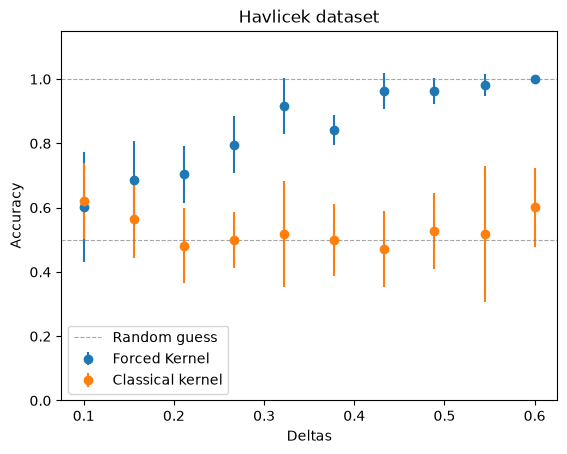

In [12]:
plt.title('Havlicek dataset')
plt.ylabel('Accuracy')
plt.xlabel('Deltas')
plt.errorbar(deltas, accuracies_q, yerr=errs_q, label='Forced Kernel', color='tab:blue', fmt='o')
plt.errorbar(deltas, accuracies_classic, yerr=errs_classic, label='Classical kernel', color='tab:orange', fmt='o')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, label='Random guess')
plt.axhline(1, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
plt.legend()
plt.savefig('Havlicek_dataset_accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.ylim(0, 1.15)
plt.show()